In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('./figures', exist_ok=True)
os.makedirs('./models', exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
df = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['stroke'].value_counts())
print("\nClass imbalance ratio:", round(df['stroke'].value_counts()[0] / df['stroke'].value_counts()[1], 2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Missing values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_marr

### EDA

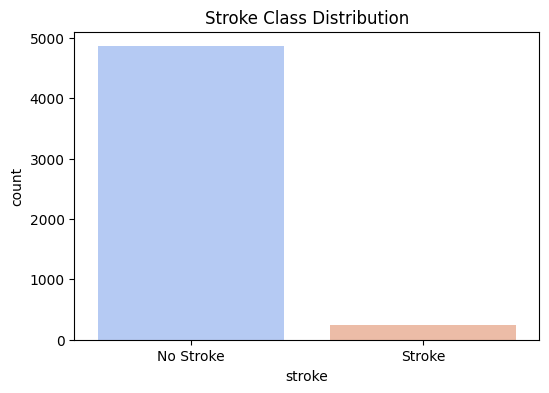

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='coolwarm')
plt.title('Stroke Class Distribution')
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.savefig('./figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

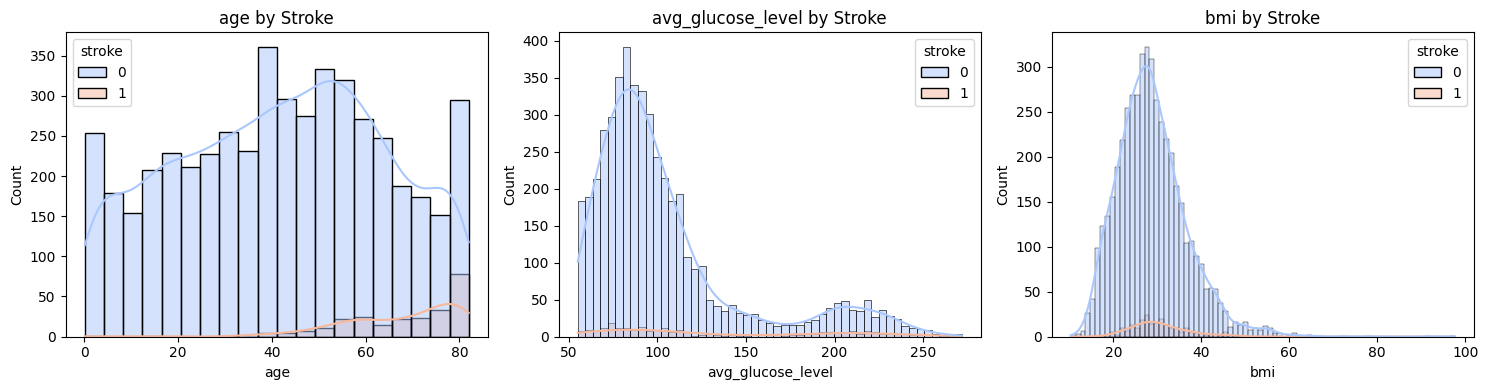

In [5]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='stroke', kde=True, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Stroke')
plt.tight_layout()
plt.savefig('./figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

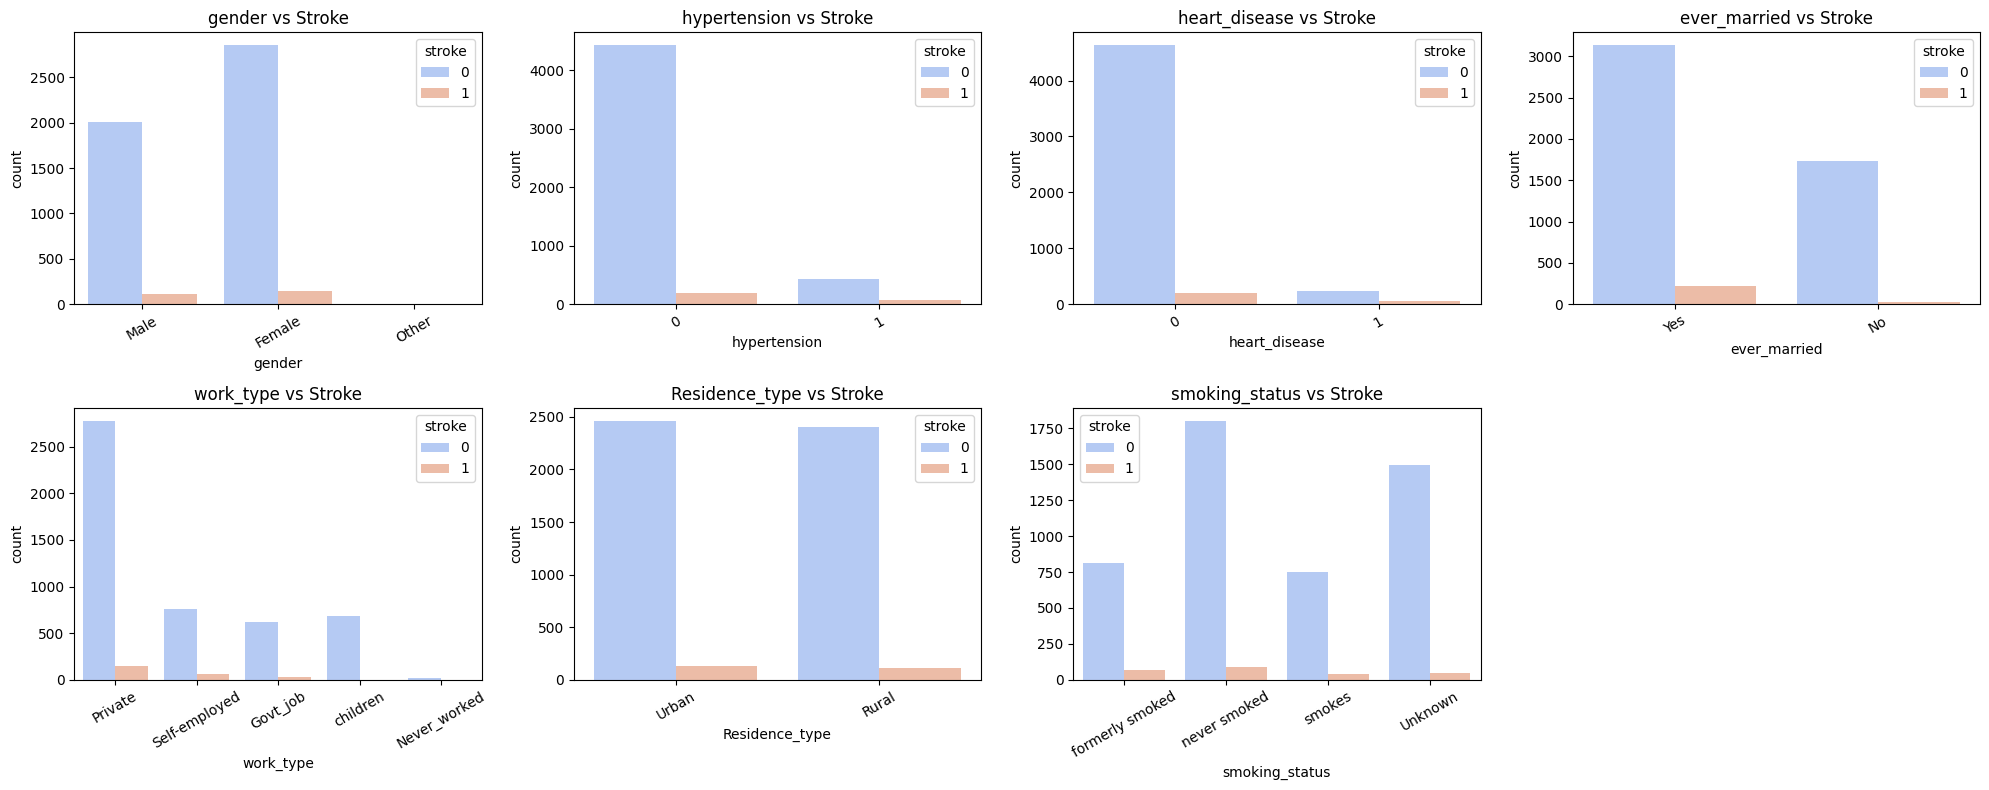

In [6]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} vs Stroke')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('./figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

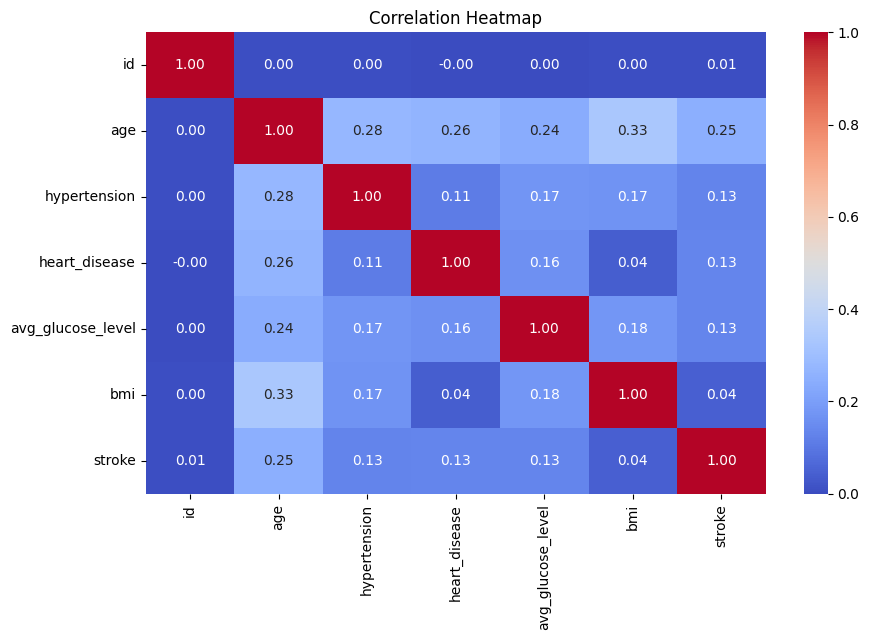

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('./figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Preprocessing

In [8]:
df = df.drop(columns=['id'])

# bmi has missing values — fill with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# drop 'Other' gender — only 1 row, causes issues in encoding
df = df[df['gender'] != 'Other']

print("Missing values after cleaning:\n", df.isnull().sum())
print("Shape:", df.shape)

Missing values after cleaning:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Shape: (5109, 11)


In [9]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          2   
1       0  61.0             0              0             1          3   
2       1  80.0             0              1             1          2   
3       0  49.0             0              0             1          2   
4       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  
0               1             228.69  36.6               1       1  
1               0             202.21  28.1               2       1  
2               0             105.92  32.5               2       1  
3               1             171.23  34.4               3       1  
4               0             174.12  24.0               2       1  
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
wo

In [10]:
X = df.drop(columns=['stroke'])
y = df['stroke']

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (5109, 10)
Target distribution:
 stroke
0    4860
1     249
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE:", dict(pd.Series(y_train_res).value_counts()))

Before SMOTE: {0: np.int64(3888), 1: np.int64(199)}
After SMOTE: {0: np.int64(3888), 1: np.int64(3888)}


In [12]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

print("Train shape:", X_train_res.shape)
print("Test shape:", X_test.shape)

Train shape: (7776, 10)
Test shape: (1022, 10)


### Pytorch conversion

In [13]:
X_train_tensor = torch.FloatTensor(X_train_res)
y_train_tensor = torch.FloatTensor(y_train_res.values)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test.values)

print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)

X_train_tensor: torch.Size([7776, 10])
X_test_tensor: torch.Size([1022, 10])


In [14]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 243
Test batches: 32


### ANN

#### Trial versions

In [15]:
class StrokAidNet(nn.Module):
    def __init__(self, input_dim):
        super(StrokAidNet, self).__init__()
        
        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Block 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Block 3
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)


input_dim = X_train_tensor.shape[1]
model = StrokAidNet(input_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

StrokAidNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 3553


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   patience=5, factor=0.5)

Using device: cuda


In [17]:
EPOCHS = 100

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Validate ---
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
            val_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Metrics ---
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    train_accs.append(train_correct / len(train_dataset))
    val_accs.append(val_correct / len(test_dataset))

    scheduler.step(val_loss / len(test_loader))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 10/100 | Train Loss: 0.3853 | Train Acc: 0.8288 | Val Loss: 0.4858 | Val Acc: 0.7270
Epoch 20/100 | Train Loss: 0.3677 | Train Acc: 0.8369 | Val Loss: 0.4369 | Val Acc: 0.7534
Epoch 30/100 | Train Loss: 0.3665 | Train Acc: 0.8398 | Val Loss: 0.4414 | Val Acc: 0.7515
Epoch 40/100 | Train Loss: 0.3608 | Train Acc: 0.8421 | Val Loss: 0.4746 | Val Acc: 0.7299
Epoch 50/100 | Train Loss: 0.3547 | Train Acc: 0.8439 | Val Loss: 0.4670 | Val Acc: 0.7348
Epoch 60/100 | Train Loss: 0.3619 | Train Acc: 0.8423 | Val Loss: 0.4525 | Val Acc: 0.7476
Epoch 70/100 | Train Loss: 0.3588 | Train Acc: 0.8436 | Val Loss: 0.4731 | Val Acc: 0.7368
Epoch 80/100 | Train Loss: 0.3552 | Train Acc: 0.8453 | Val Loss: 0.4449 | Val Acc: 0.7534
Epoch 90/100 | Train Loss: 0.3566 | Train Acc: 0.8448 | Val Loss: 0.4128 | Val Acc: 0.7798
Epoch 100/100 | Train Loss: 0.3520 | Train Acc: 0.8468 | Val Loss: 0.4581 | Val Acc: 0.7397


In [18]:
class StrokAidNetV2(nn.Module):
    def __init__(self, input_dim):
        super(StrokAidNetV2, self).__init__()
        
        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Block 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Block 4
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)


model = StrokAidNetV2(input_dim).to(device)

# Lower LR + stronger weight decay to fight overfitting
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=7, factor=0.5, verbose=True)
criterion = nn.BCELoss()

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

StrokAidNetV2(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=16, out_features=1, bias=True)
    (17): Sigmoid()
  )
)
Total parameters: 12769


In [19]:
EPOCHS = 100

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Validate ---
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
            val_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Metrics ---
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    train_accs.append(train_correct / len(train_dataset))
    val_accs.append(val_correct / len(test_dataset))

    scheduler.step(val_loss / len(test_loader))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 10/100 | Train Loss: 0.3991 | Train Acc: 0.8221 | Val Loss: 0.4695 | Val Acc: 0.7221
Epoch 20/100 | Train Loss: 0.3838 | Train Acc: 0.8336 | Val Loss: 0.5014 | Val Acc: 0.6957
Epoch 30/100 | Train Loss: 0.3744 | Train Acc: 0.8347 | Val Loss: 0.4392 | Val Acc: 0.7436
Epoch 40/100 | Train Loss: 0.3738 | Train Acc: 0.8373 | Val Loss: 0.4352 | Val Acc: 0.7505
Epoch 50/100 | Train Loss: 0.3644 | Train Acc: 0.8398 | Val Loss: 0.4330 | Val Acc: 0.7515
Epoch 60/100 | Train Loss: 0.3719 | Train Acc: 0.8360 | Val Loss: 0.4296 | Val Acc: 0.7524
Epoch 70/100 | Train Loss: 0.3656 | Train Acc: 0.8412 | Val Loss: 0.4147 | Val Acc: 0.7642
Epoch 80/100 | Train Loss: 0.3631 | Train Acc: 0.8427 | Val Loss: 0.4292 | Val Acc: 0.7524
Epoch 90/100 | Train Loss: 0.3735 | Train Acc: 0.8359 | Val Loss: 0.4387 | Val Acc: 0.7446
Epoch 100/100 | Train Loss: 0.3660 | Train Acc: 0.8426 | Val Loss: 0.4113 | Val Acc: 0.7622


#### Final

In [40]:
class StrokAidNetV3(nn.Module):
    def __init__(self, input_dim):
        super(StrokAidNetV3, self).__init__()
        
        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            
            # Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            
            # Block 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            # Block 4
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            # Output
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)


# --- Setup ---
EPOCHS = 150
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = StrokAidNetV3(input_dim).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCELoss()

# --- Early Stopping ---
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 15
best_model_state = None

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

StrokAidNetV3(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.1)
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=16, out_featur

In [43]:


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Validate ---
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
            val_correct += ((preds >= 0.5) == y_batch).sum().item()

    # --- Metrics ---
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    train_accs.append(train_correct / len(train_dataset))
    val_accs.append(val_correct / len(test_dataset))

    scheduler.step(val_loss / len(test_loader))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 10/150 | Train Loss: 0.3221 | Train Acc: 0.8633 | Val Loss: 0.4302 | Val Acc: 0.7808
Epoch 20/150 | Train Loss: 0.3158 | Train Acc: 0.8647 | Val Loss: 0.4207 | Val Acc: 0.7798
Epoch 30/150 | Train Loss: 0.3204 | Train Acc: 0.8637 | Val Loss: 0.4466 | Val Acc: 0.7505
Epoch 40/150 | Train Loss: 0.3078 | Train Acc: 0.8726 | Val Loss: 0.4082 | Val Acc: 0.7916
Epoch 50/150 | Train Loss: 0.3098 | Train Acc: 0.8679 | Val Loss: 0.4216 | Val Acc: 0.7818
Epoch 60/150 | Train Loss: 0.3116 | Train Acc: 0.8686 | Val Loss: 0.4199 | Val Acc: 0.7798
Epoch 70/150 | Train Loss: 0.3060 | Train Acc: 0.8731 | Val Loss: 0.4063 | Val Acc: 0.7984
Epoch 80/150 | Train Loss: 0.3067 | Train Acc: 0.8719 | Val Loss: 0.4059 | Val Acc: 0.7935
Epoch 90/150 | Train Loss: 0.3084 | Train Acc: 0.8674 | Val Loss: 0.4089 | Val Acc: 0.7838
Epoch 100/150 | Train Loss: 0.3079 | Train Acc: 0.8711 | Val Loss: 0.3987 | Val Acc: 0.7935
Epoch 110/150 | Train Loss: 0.3083 | Train Acc: 0.8697 | Val Loss: 0.3987 | Val Acc: 0.79

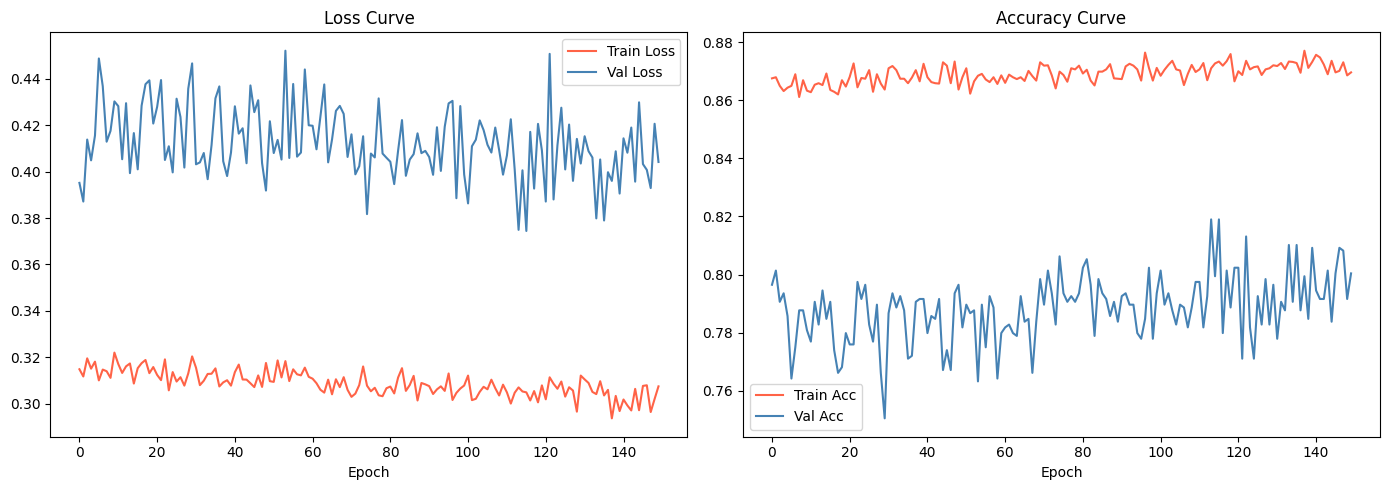

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='tomato')
axes[0].plot(val_losses, label='Val Loss', color='steelblue')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='tomato')
axes[1].plot(val_accs, label='Val Acc', color='steelblue')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('./figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluation

In [46]:
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = model(X_batch)
        preds = (probs >= 0.35).float()
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [48]:
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}")

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.97      0.77      0.86       972
      Stroke       0.11      0.58      0.19        50

    accuracy                           0.76      1022
   macro avg       0.54      0.67      0.52      1022
weighted avg       0.93      0.76      0.82      1022

ROC-AUC Score: 0.7702


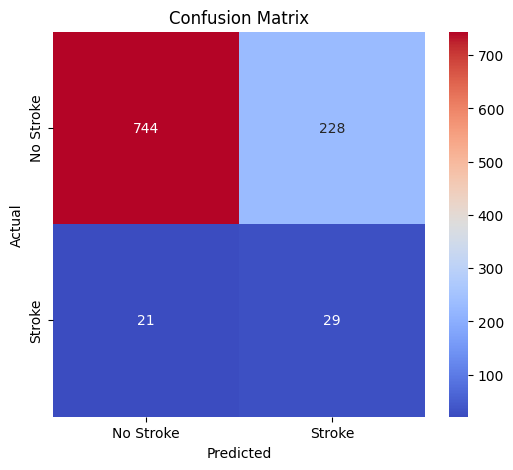

In [49]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('./figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

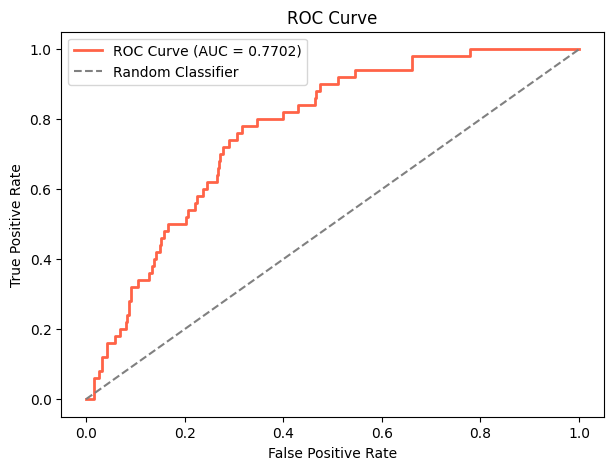

In [50]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('./figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

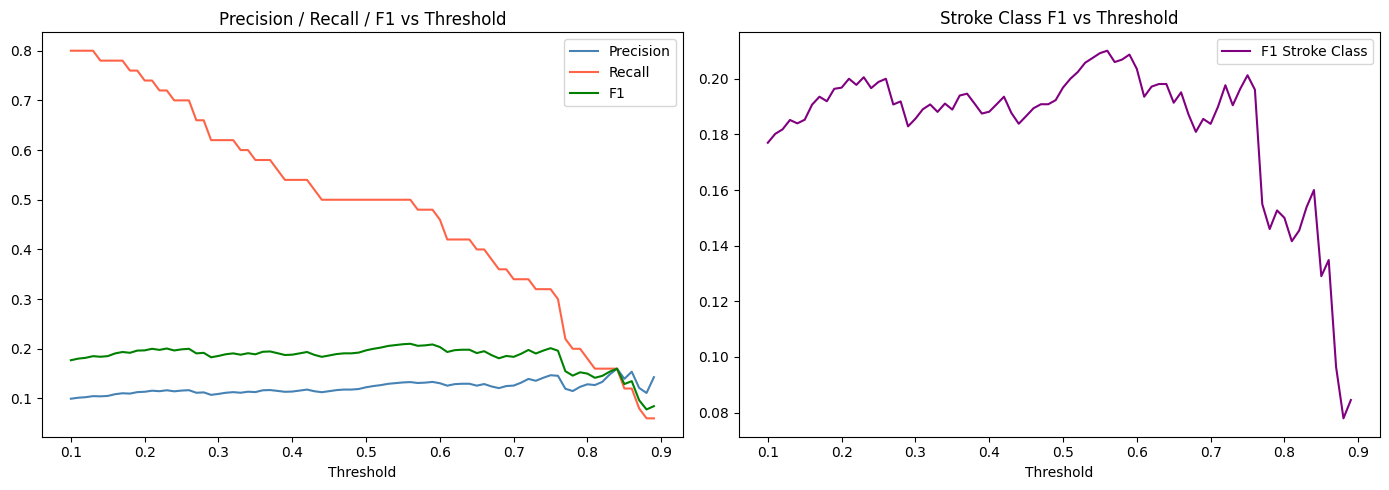


Best threshold by Stroke F1: 0.56
Precision: 0.1330 | Recall: 0.5000 | F1 Stroke: 0.2101


In [51]:
# threshold analysis
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.01)
results = []

for t in thresholds:
    preds_t = (all_probs >= t).astype(int)
    p = precision_score(all_labels, preds_t, zero_division=0)
    r = recall_score(all_labels, preds_t)
    f1 = f1_score(all_labels, preds_t)
    f1_stroke = f1_score(all_labels, preds_t, pos_label=1)
    results.append({'threshold': round(t, 2), 'precision': p, 'recall': r, 
                    'f1': f1, 'f1_stroke': f1_stroke})

results_df = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['precision'], label='Precision', color='steelblue')
axes[0].plot(results_df['threshold'], results_df['recall'], label='Recall', color='tomato')
axes[0].plot(results_df['threshold'], results_df['f1'], label='F1', color='green')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].legend()

axes[1].plot(results_df['threshold'], results_df['f1_stroke'], color='purple', label='F1 Stroke Class')
axes[1].set_title('Stroke Class F1 vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('./figures/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Best threshold by stroke F1
best_row = results_df.loc[results_df['f1_stroke'].idxmax()]
print(f"\nBest threshold by Stroke F1: {best_row['threshold']}")
print(f"Precision: {best_row['precision']:.4f} | Recall: {best_row['recall']:.4f} | F1 Stroke: {best_row['f1_stroke']:.4f}")

In [56]:
import joblib

# Save model
torch.save({
    'model_state_dict': best_model_state,
    'input_dim': input_dim,
    'threshold': 0.35,
    'architecture': 'StrokAidNetV3'
}, './models/strokaid_model.pth')

# Save scaler
joblib.dump(scaler, './models/strokaid_scaler.pkl')

# Save feature names for app.py
feature_names = X.columns.tolist()
joblib.dump(feature_names, './models/strokaid_features.pkl')

print("Saved:")
print("  ./models/strokaid_model.pth")
print("  ./models/strokaid_scaler.pkl")
print("  ./models/strokaid_features.pkl")

Saved:
  ./models/strokaid_model.pth
  ./models/strokaid_scaler.pkl
  ./models/strokaid_features.pkl
